In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
train_dir = r"D:\AI smart manufacturing\visual inspection\Dataset\NEU-DET\train\images"
val_dir = r"D:\AI smart manufacturing\visual inspection\Dataset\NEU-DET\validation\images"

IMG_SIZE = 224
BATCH_SIZE = 32

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # FULLY FREEZE

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_neu_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.8167 - loss: 0.5376 - val_accuracy: 0.9472 - val_loss: 0.1871
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9750 - loss: 0.1006 - val_accuracy: 0.9694 - val_loss: 0.1125
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9826 - loss: 0.0715 - val_accuracy: 0.9611 - val_loss: 0.1016
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9792 - loss: 0.0542 - val_accuracy: 0.9639 - val_loss: 0.1023
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9875 - loss: 0.0549 - val_accuracy: 0.9750 - val_loss: 0.0777
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9778 - loss: 0.0656 - val_accuracy: 0.9667 - val_loss: 0.0987
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9917 - loss: 0.0342 - val_accuracy: 0.9722 - val_loss: 0.0662
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9882 - loss: 0.0348 - val_accuracy: 0.9694 - val_loss

In [9]:
print("Train Classes:", train_generator.class_indices)
print("Validation Classes:", val_generator.class_indices)

Train Classes: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}
Validation Classes: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [13]:
model.save("neu_defect_classifier.keras")

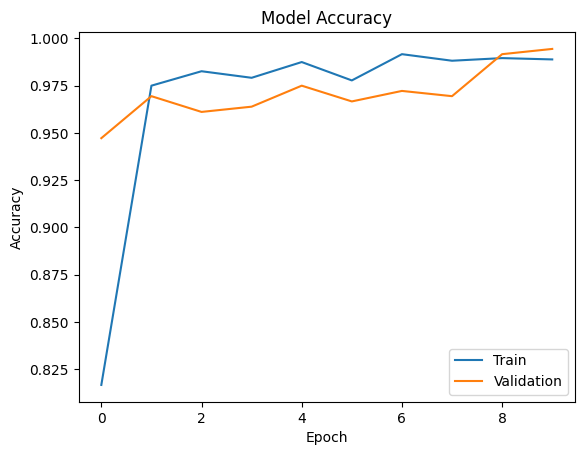

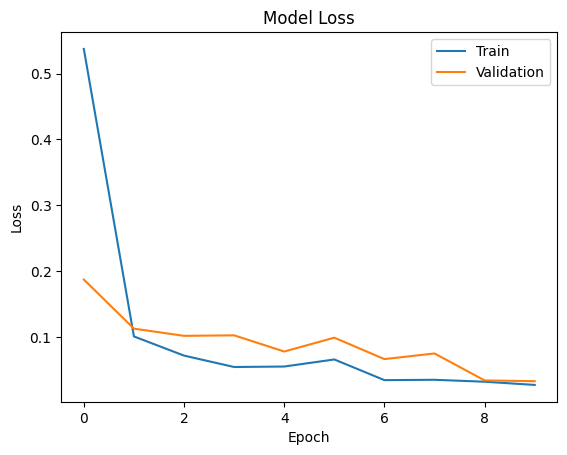

In [14]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


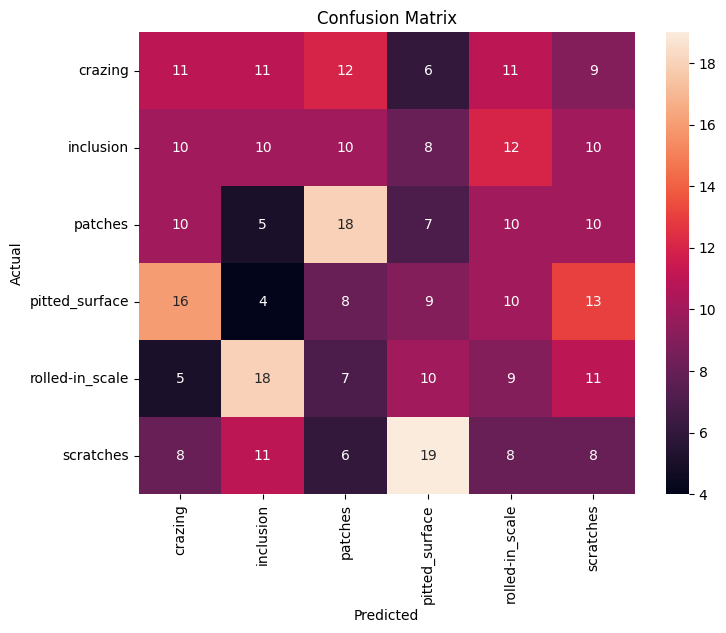

              precision    recall  f1-score   support

           0       0.18      0.18      0.18        60
           1       0.17      0.17      0.17        60
           2       0.30      0.30      0.30        60
           3       0.15      0.15      0.15        60
           4       0.15      0.15      0.15        60
           5       0.13      0.13      0.13        60

    accuracy                           0.18       360
   macro avg       0.18      0.18      0.18       360
weighted avg       0.18      0.18      0.18       360



In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_generator.reset()
pred = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True,
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(true_classes, pred_classes))

In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

cnn_model = load_model("neu_defect_classifier.keras")

uploaded_file = st.file_uploader("Upload Steel Surface Image")

if uploaded_file is not None:
    img = image.load_img(uploaded_file, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = cnn_model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    classes = ['crazing','inclusion','patches',
               'pitted_surface','rolled-in_scale','scratches']

    st.write("Defect Type:", classes[class_index])
    st.write("Confidence:", round(confidence*100,2), "%")

NameError: name 'st' is not defined